In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'coco-2017-dataset' dataset.
Path to dataset files: /kaggle/input/coco-2017-dataset


In [2]:
import os
import zipfile


In [ ]:
!pip install matplotlib-venn

In [4]:
images_path = "/content/val2017"
annotations_path = "/content/annotations/instances_val2017.json"


In [5]:
# === Core Python ===
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt

# === Torch / Deep Learning ===
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

# === Image Processing ===
from PIL import Image
import cv2

# === COCO API ===
from pycocotools.coco import COCO

# === Albumentations (for transforms) ===
import albumentations as A
from albumentations.pytorch import ToTensorV2

# === TQDM (progress bar) ===
from tqdm import tqdm


In [6]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

from PIL import Image
import cv2

from pycocotools.coco import COCO

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm


In [7]:
class CocoMaskedDataset(Dataset):
    def __init__(self, images_path, annotations_path, transform=None):
        self.images_path = images_path
        self.transform = transform

        with open(annotations_path, "r") as f:
            coco_data = json.load(f)

        self.images = {img["id"]: img["file_name"] for img in coco_data["images"]}
        self.annotations = {}
        for ann in coco_data["annotations"]:
            img_id = ann["image_id"]
            if img_id not in self.annotations:
                self.annotations[img_id] = []
            self.annotations[img_id].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_id = list(self.images.keys())[idx]
        img_name = self.images[img_id]
        img_path = os.path.join(self.images_path, img_name)

        img = np.array(Image.open(img_path).convert("RGB"))
        height, width = img.shape[:2]
        mask = np.zeros((height, width), dtype=np.uint8)

        anns = self.annotations.get(img_id, [])
        for ann in anns:
            if ann.get("iscrowd", 0):
                continue
            if "segmentation" in ann and isinstance(ann["segmentation"], list):
                for seg in ann["segmentation"]:
                    poly = np.array(seg).reshape((-1, 2))
                    cv2.fillPoly(mask, [poly.astype(np.int32)], 1)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]

        return img, mask


In [8]:
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


In [9]:
!ls /content


drive  sample_data


In [10]:
import kagglehub

# Download COCO 2017 dataset (val + annotations)
path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")
print("Path to dataset files:", path)

# Check folders inside
!ls $path


Using Colab cache for faster access to the 'coco-2017-dataset' dataset.
Path to dataset files: /kaggle/input/coco-2017-dataset
coco2017


In [11]:
!wget http://images.cocodataset.org/zips/val2017.zip
!unzip -q val2017.zip -d /content/

--2025-09-23 09:28:34--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.28.136, 3.5.29.243, 3.5.28.125, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.28.136|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 777.80M  63.5MB/s    in 16s     

2025-09-23 09:28:50 (48.6 MB/s) - ‘val2017.zip’ saved [815585330/815585330]



In [12]:
import zipfile

zip_path = "/content/drive/MyDrive/AI-VISION/annotations_trainval2017.zip"
extract_dir = "/content/annotations_trainval2017"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

In [13]:
get_ipython().system('wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip')

--2025-09-23 09:29:23--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.192.226, 52.217.164.17, 52.216.48.185, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.192.226|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotations_trainva 100%[===================>] 241.19M  55.2MB/s    in 4.7s    

2025-09-23 09:29:28 (51.3 MB/s) - ‘annotations_trainval2017.zip’ saved [252907541/252907541]



In [14]:
!ls /content
!ls /content/annotations


annotations_trainval2017      drive	   val2017
annotations_trainval2017.zip  sample_data  val2017.zip
ls: cannot access '/content/annotations': No such file or directory


In [15]:
images_path = "/content/val2017"
annotations_path = "/content/annotations_trainval2017/annotations/instances_val2017.json"


In [16]:
import os
import json
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
from skimage.draw import polygon

class CocoMaskedDataset(Dataset):
    def __init__(self, images_path, annotations_path, transform=None):
        self.images_path = images_path
        self.transform = transform

        with open(annotations_path, "r") as f:
            coco_data = json.load(f)

        # Map image_id → file_name
        self.images = {img["id"]: img["file_name"] for img in coco_data["images"]}

        # Group annotations by image_id
        self.annotations = {}
        for ann in coco_data["annotations"]:
            img_id = ann["image_id"]
            if img_id not in self.annotations:
                self.annotations[img_id] = []
            self.annotations[img_id].append(ann)

        self.ids = list(self.images.keys())

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_path = os.path.join(self.images_path, self.images[img_id])
        img = np.array(Image.open(img_path).convert("RGB"))

        # Build mask
        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        for ann in self.annotations.get(img_id, []):
            for seg in ann["segmentation"]:
                if isinstance(seg, list):  # polygon
                    coords = np.array(seg).reshape(-1, 2)
                    rr, cc = polygon(coords[:, 1], coords[:, 0], mask.shape)
                    mask[rr, cc] = 1

        # Apply transforms if provided
        if self.transform:
            transformed = self.transform(image=img, mask=mask)
            img = transformed["image"]
            mask = transformed["mask"]
        else:
            img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).long()

        return img, mask


In [17]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Validation transforms (resize + normalize + convert to tensor)
val_transform = A.Compose([
    A.Resize(256, 256),  # keep small for speed
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


In [18]:
from torch.utils.data import DataLoader


In [21]:
images_path = "/content/val2017"
annotations_path = "/content/annotations_trainval2017/annotations/instances_val2017.json"

dataset = CocoMaskedDataset(images_path, annotations_path, transform=val_transform)
val_loader = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=2)



In [24]:
dataset = CocoMaskedDataset(images_path, annotations_path, transform=val_transform)
val_loader = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=0)


In [25]:
import torch
import torchvision
from torchvision import models

# Pick device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model architecture (DeepLabV3 with ResNet50 backbone, pretrained on COCO)
num_classes = 2  # foreground + background (update if different)
model = models.segmentation.deeplabv3_resnet50(pretrained=False, num_classes=num_classes)

# Move to device
model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 59.9MB/s]


In [26]:
import torch
import torchvision
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained DeepLabV3 with ResNet50 backbone
model = models.segmentation.deeplabv3_resnet50(pretrained=True)
model = model.to(device)
model.eval()

print("✅ Pretrained DeepLabV3 loaded successfully")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 176MB/s]


✅ Pretrained DeepLabV3 loaded successfully


In [27]:
# Example save after training
torch.save(model.state_dict(), "deeplabv3_custom_final.pth")


In [28]:
model.load_state_dict(torch.load("deeplabv3_custom_final.pth", map_location=device))


<All keys matched successfully>

In [29]:
dataset = CocoMaskedDataset(images_path, annotations_path, transform=val_transform)
val_loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0)


In [30]:
import torch
import torchvision
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model (binary: background vs object)
num_classes = 2
model = models.segmentation.deeplabv3_resnet50(pretrained=True)
model.classifier[-1] = torch.nn.Conv2d(256, num_classes, kernel_size=1)
model = model.to(device)


In [31]:
import torchvision.transforms as T

train_transform = T.Compose([
    T.Resize((256, 256)),        # resize all images/masks to same size
    T.ToTensor(),                # convert PIL → tensor
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])  # standard ImageNet normalization
])


In [32]:
from torch.utils.data import DataLoader, Subset
import random

# Full dataset
dataset = CocoMaskedDataset(images_path, annotations_path, transform=train_transform)

# Take a small subset (e.g., 200 images)
subset_indices = random.sample(range(len(dataset)), 200)
train_subset = Subset(dataset, subset_indices)

train_loader = DataLoader(train_subset, batch_size=2, shuffle=True, num_workers=0)


In [33]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


In [34]:
dataset = CocoMaskedDataset(images_path, annotations_path, transform=train_transform)


In [35]:
from torch.utils.data import DataLoader, Subset
import random

# Take a subset for quick training (200 samples)
subset_indices = random.sample(range(len(dataset)), 200)
train_subset = Subset(dataset, subset_indices)

train_loader = DataLoader(train_subset, batch_size=2, shuffle=True, num_workers=0)

print("✅ Dataset ready with", len(train_subset), "samples")


✅ Dataset ready with 200 samples


In [36]:
state_dict = torch.load("/content/deeplabv3_custom_final.pth", map_location=device)

# Remove classifier layer weights (mismatch)
for key in list(state_dict.keys()):
    if "classifier.4" in key:   # final layer
        del state_dict[key]

# Load the rest
model.load_state_dict(state_dict, strict=False)
print("✅ Model loaded (backbone only, classifier re-initialized)")


✅ Model loaded (backbone only, classifier re-initialized)


Epoch 1/20  avg_loss: 0.5028


Epoch 2/20  avg_loss: 0.2772


Epoch 3/20  avg_loss: 0.2418


Epoch 4/20  avg_loss: 0.2192


Epoch 5/20  avg_loss: 0.2180


...

Epoch 16/20  avg_loss: 0.1358


Epoch 17/20  avg_loss: 0.1295


Epoch 18/20  avg_loss: 0.1200


Epoch 19/20  avg_loss: 0.1169


Epoch 20/20  avg_loss: 0.1096
✅ Saved: deeplabv3_custom_finetuned_head.pth


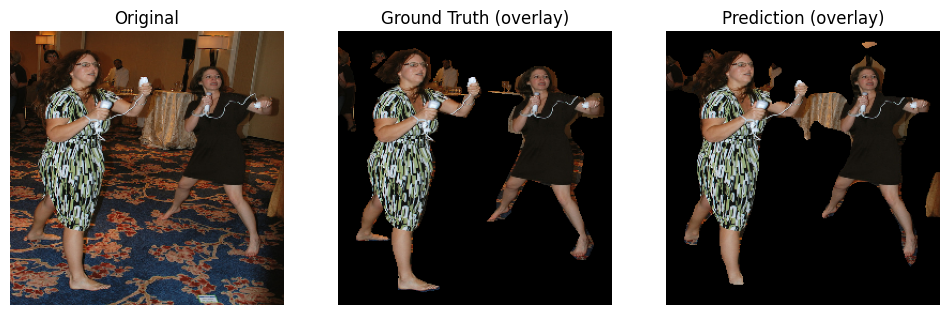

In [50]:
# === Fine-tune classifier head only (run this cell) ===
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Create a small training subset (200 samples or fewer if dataset smaller)
subset_size = min(50, len(dataset))
subset_indices = random.sample(range(len(dataset)), subset_size)
train_subset = Subset(dataset, subset_indices)
train_loader = DataLoader(train_subset, batch_size=4, shuffle=True, num_workers=2)

# Freeze everything except classifier and aux_classifier
for name, param in model.named_parameters():
    if ("classifier" in name) or ("aux_classifier" in name):
        param.requires_grad = True
    else:
        param.requires_grad = False

# Optimizer only for trainable params (the classifier head)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Train head for a few epochs
num_epochs = 20
model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)["out"]          # [B, C, H, W]
        loss = criterion(outputs, masks.long())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=running_loss / (loop.n + 1))

    print(f"Epoch {epoch+1}/{num_epochs}  avg_loss: {running_loss/len(train_loader):.4f}")

# Save the fine-tuned-head checkpoint
torch.save(model.state_dict(), "deeplabv3_custom_finetuned_head.pth")
print("✅ Saved: deeplabv3_custom_finetuned_head.pth")

# === Quick evaluation + visualization on one validation batch ===
model.eval()
with torch.no_grad():
    images, masks = next(iter(val_loader))
    images = images.to(device)
    masks = masks.to(device)
    outputs = model(images)["out"]
    preds = torch.argmax(outputs, dim=1).cpu().numpy()   # (B, H, W)

# Un-normalize for display
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

num_show = min(4, images.shape[0])
for i in range(num_show):
    img = images[i].cpu().permute(1,2,0).numpy()     # (H,W,3)
    img = np.clip(img * std + mean, 0, 1)
    gt = masks[i].cpu().numpy()
    pred = preds[i]

    gt_overlay = np.zeros_like(img)
    gt_overlay[gt == 1] = img[gt == 1]

    pred_overlay = np.zeros_like(img)
    pred_overlay[pred == 1] = img[pred == 1]

    fig, axs = plt.subplots(1,3, figsize=(12,4))
    axs[0].imshow(img); axs[0].set_title("Original"); axs[0].axis("off")
    axs[1].imshow(gt_overlay); axs[1].set_title("Ground Truth (overlay)"); axs[1].axis("off")
    axs[2].imshow(pred_overlay); axs[2].set_title("Prediction (overlay)"); axs[2].axis("off")
    plt.show()


Epoch 1/30  avg_loss: 0.3035


Epoch 2/30  avg_loss: 0.2026


Epoch 3/30  avg_loss: 0.1714


Epoch 4/30  avg_loss: 0.1619


Epoch 5/30  avg_loss: 0.1453


...

Epoch 26/30  avg_loss: 0.1550


Epoch 27/30  avg_loss: 0.1290


Epoch 28/30  avg_loss: 0.1107


Epoch 29/30  avg_loss: 0.1042


Epoch 30/30  avg_loss: 0.1008
✅ Saved: deeplabv3_custom_finetuned_head.pth


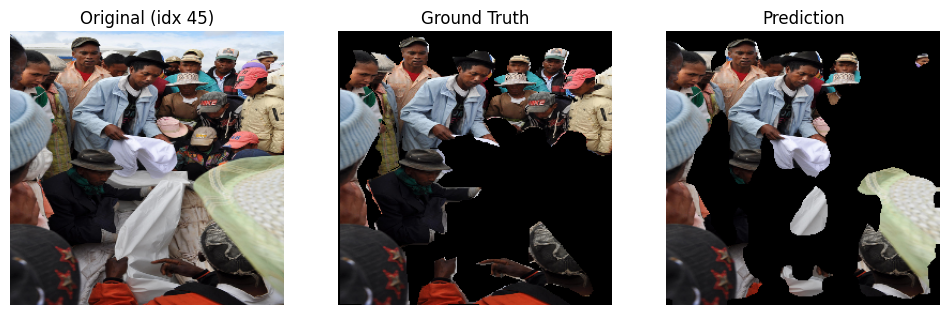

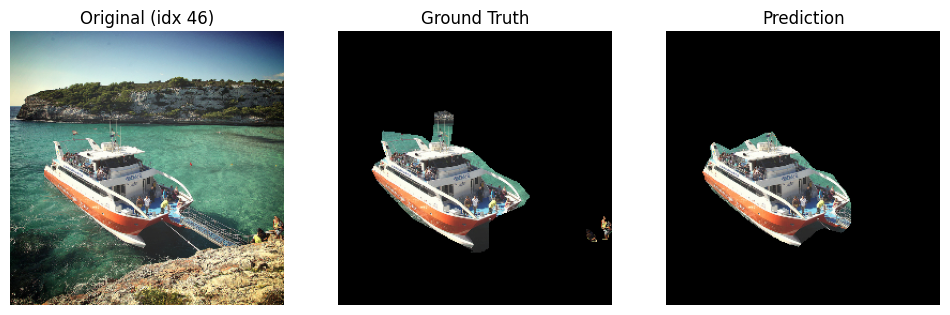

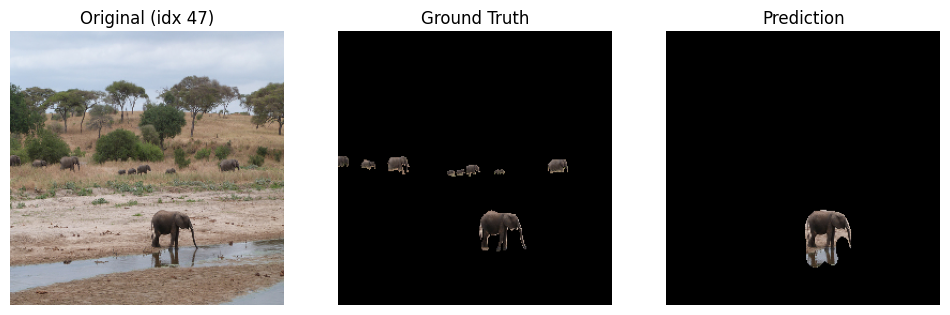

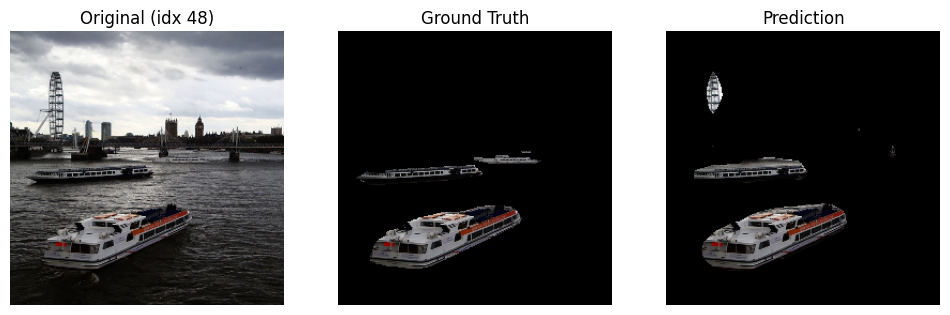

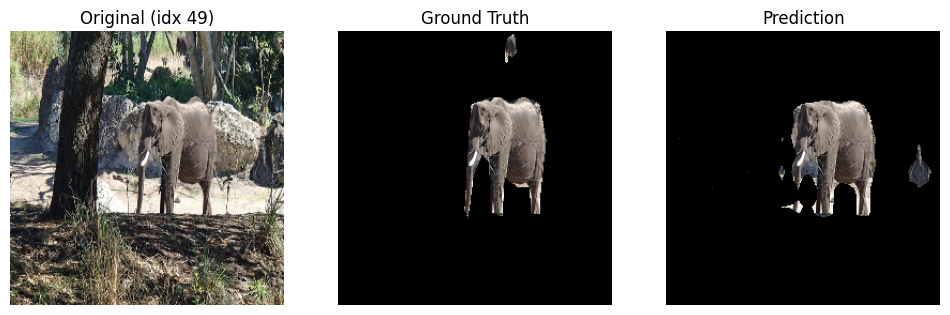

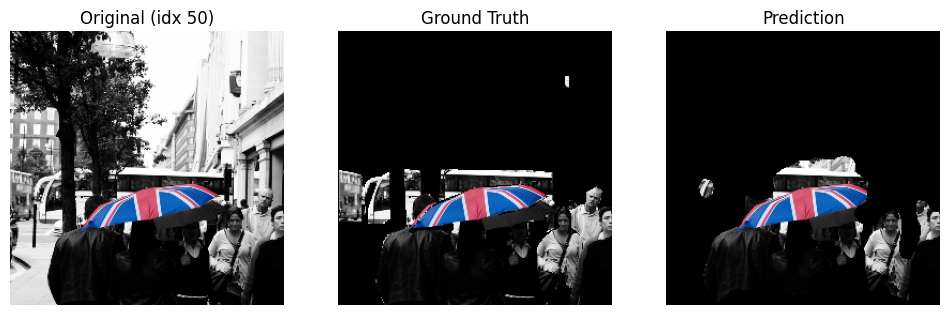

In [47]:
# === Fine-tune classifier head only (run this cell) ===
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Create a small training subset (50 samples or fewer if dataset smaller)
subset_size = min(50, len(dataset))
subset_indices = random.sample(range(len(dataset)), subset_size)
train_subset = Subset(dataset, subset_indices)
train_loader = DataLoader(train_subset, batch_size=4, shuffle=True, num_workers=2)

# Freeze everything except classifier and aux_classifier
for name, param in model.named_parameters():
    if ("classifier" in name) or ("aux_classifier" in name):
        param.requires_grad = True
    else:
        param.requires_grad = False

# Optimizer only for trainable params (the classifier head)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Train head for a few epochs
num_epochs = 30
model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)["out"]          # [B, C, H, W]
        loss = criterion(outputs, masks.long())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=running_loss / (loop.n + 1))

    print(f"Epoch {epoch+1}/{num_epochs}  avg_loss: {running_loss/len(train_loader):.4f}")

# Save the fine-tuned-head checkpoint
torch.save(model.state_dict(), "deeplabv3_custom_finetuned_head.pth")
print("✅ Saved: deeplabv3_custom_finetuned_head.pth")

# === Quick evaluation + visualization for dataset indices 20–25 ===
model.eval()
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

with torch.no_grad():
    for idx in range(44, 50):   # indices 19→24 == dataset samples 20→25
        img, mask = dataset[idx]
        img_input = img.unsqueeze(0).to(device)
        mask = mask.to(device)

        outputs = model(img_input)["out"]
        pred = torch.argmax(outputs, dim=1).cpu().squeeze().numpy()

        # Un-normalize for display
        img = img.permute(1,2,0).cpu().numpy()
        img = np.clip(img * std + mean, 0, 1)
        gt = mask.cpu().numpy()

        # Apply mask overlays
        gt_overlay = np.zeros_like(img)
        gt_overlay[gt == 1] = img[gt == 1]
        # Show all predicted classes except background (class 0)
        pred_overlay = np.zeros_like(img)
        pred_overlay[pred != 0] = img[pred != 0]


        # Plot side-by-side
        fig, axs = plt.subplots(1,3, figsize=(12,4))
        axs[0].imshow(img); axs[0].set_title(f"Original (idx {idx+1})"); axs[0].axis("off")
        axs[1].imshow(gt_overlay); axs[1].set_title("Ground Truth"); axs[1].axis("off")
        axs[2].imshow(pred_overlay); axs[2].set_title("Prediction"); axs[2].axis("off")
        plt.show()


Epoch 1/30  avg_loss: 0.3438


Epoch 2/30  avg_loss: 0.2950


Epoch 3/30  avg_loss: 0.2561


Epoch 4/30  avg_loss: 0.2093


Epoch 5/30  avg_loss: 0.1864


...

Epoch 26/30  avg_loss: 0.0964


Epoch 27/30  avg_loss: 0.0917


Epoch 28/30  avg_loss: 0.0869


Epoch 29/30  avg_loss: 0.0873


Epoch 30/30  avg_loss: 0.0851
✅ Saved: deeplabv3_custom_finetuned_head.pth


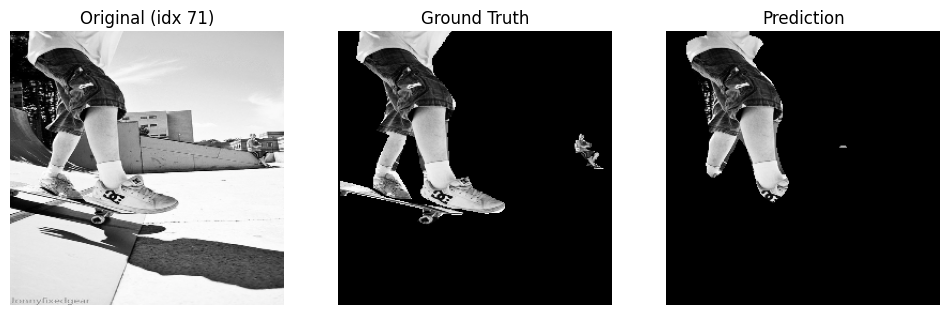

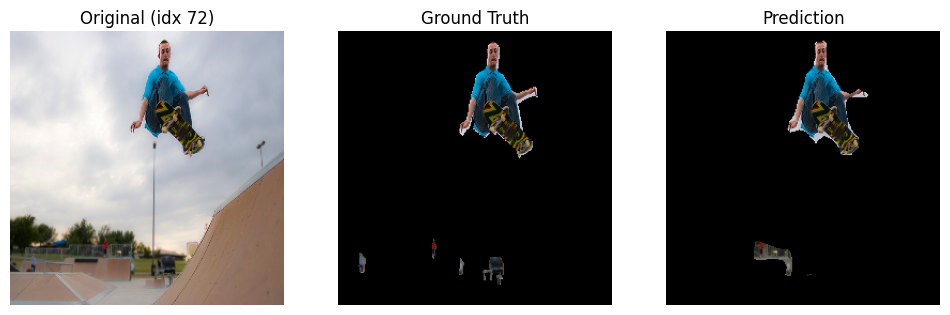

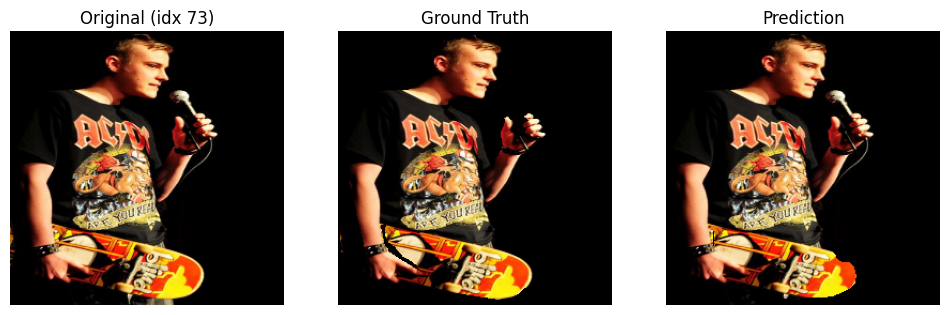

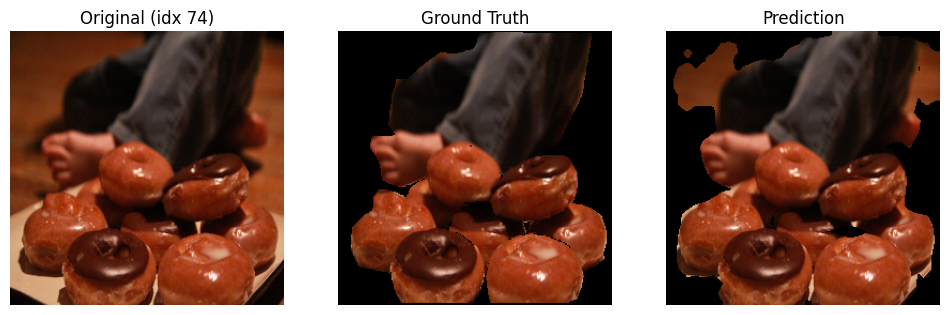

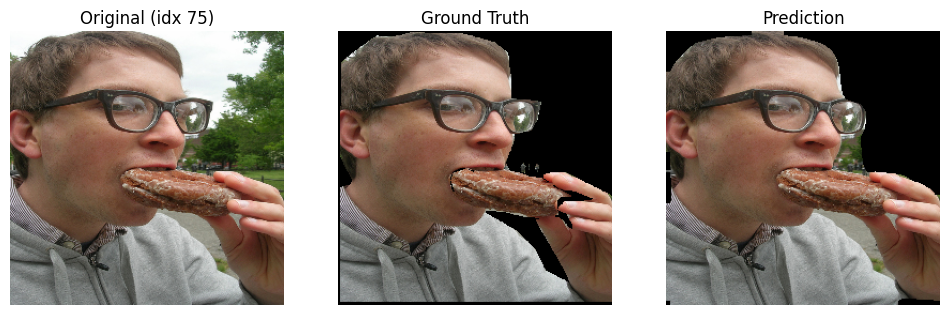

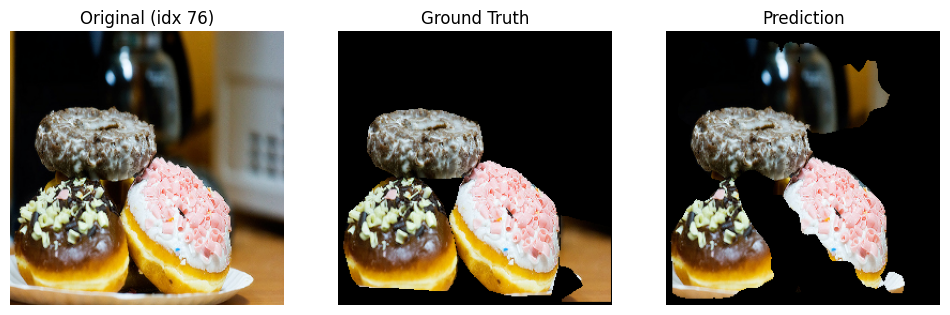

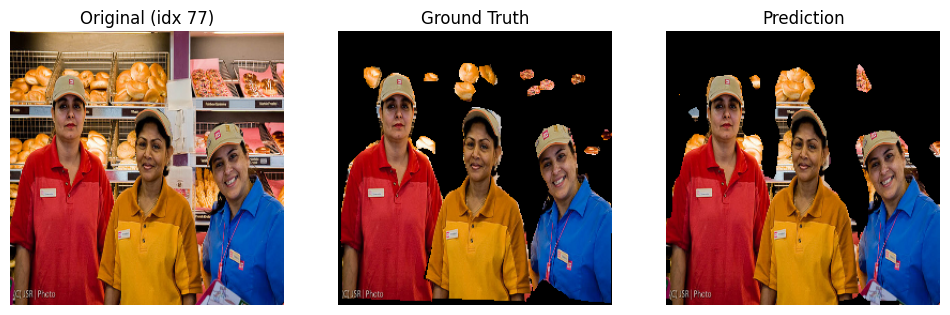

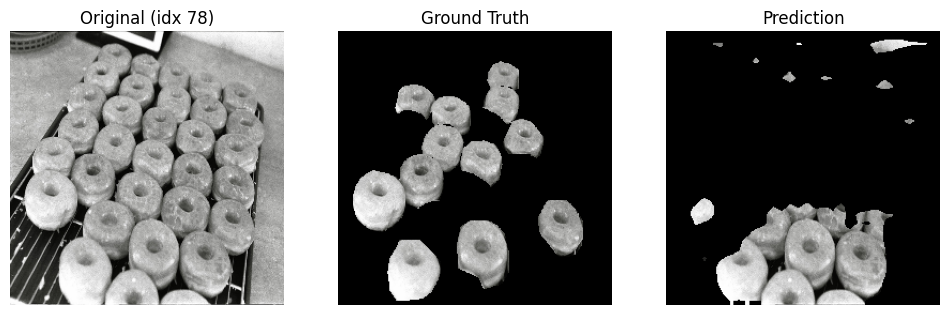

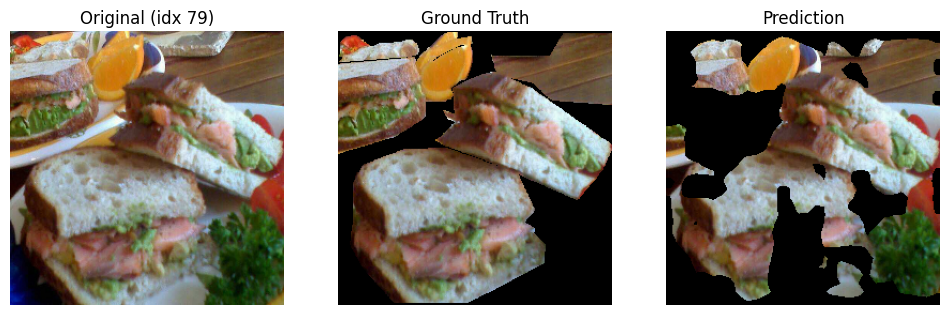

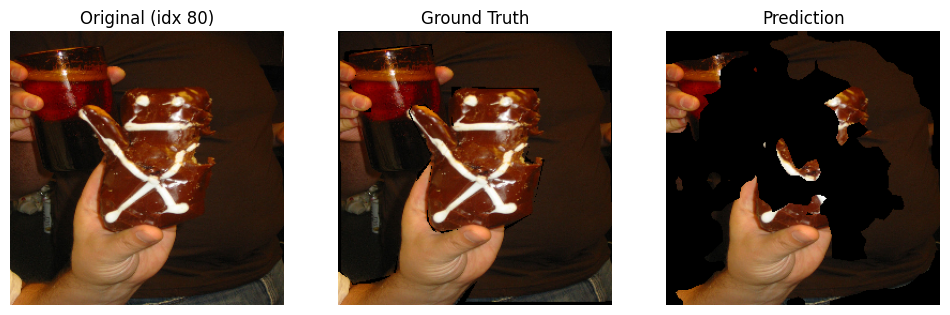

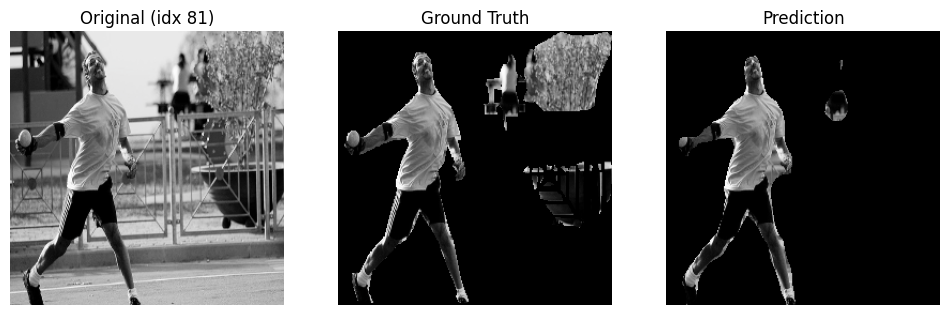

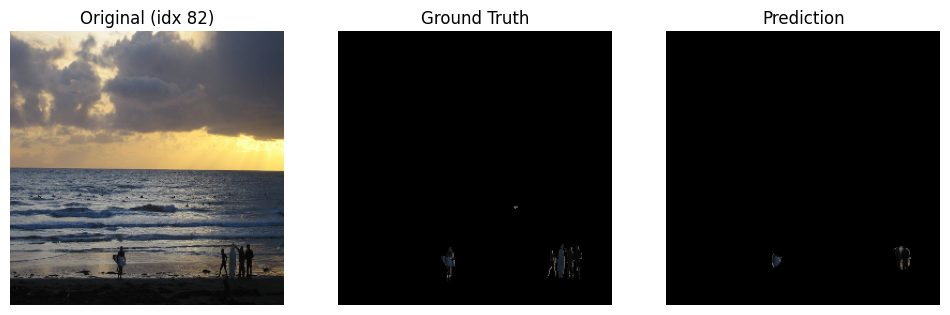

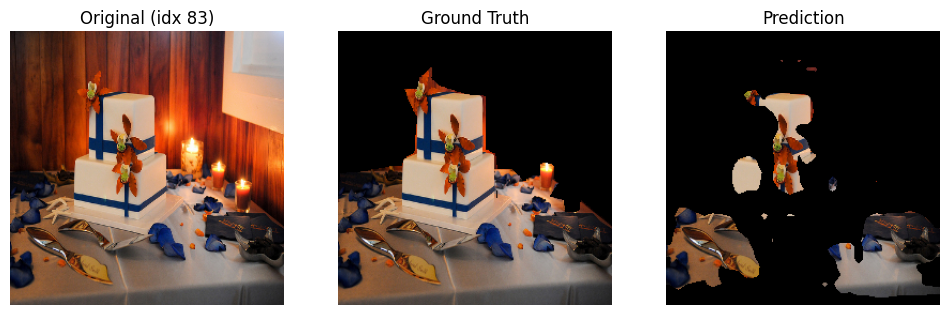

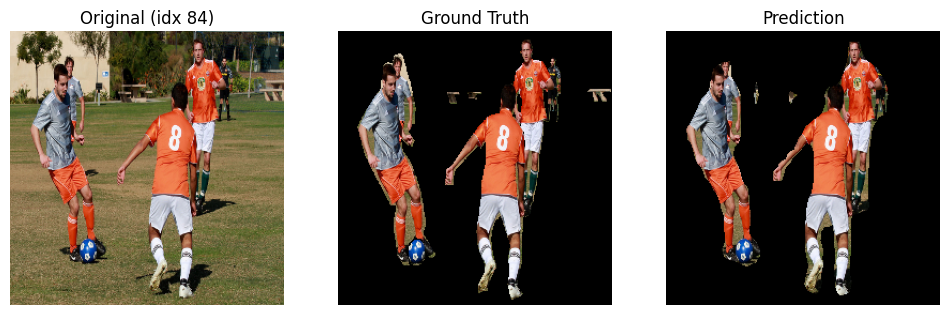

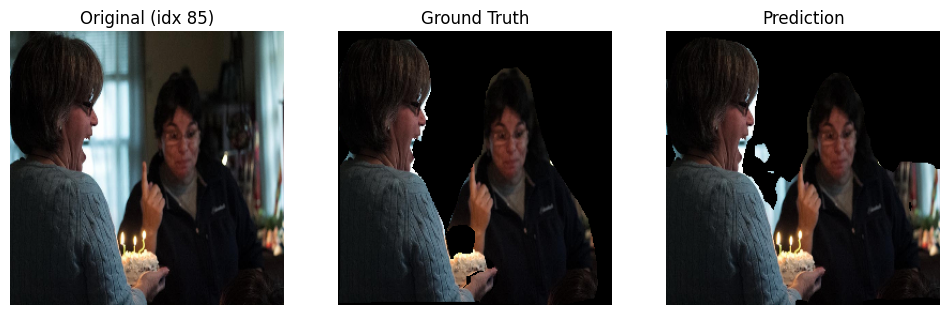

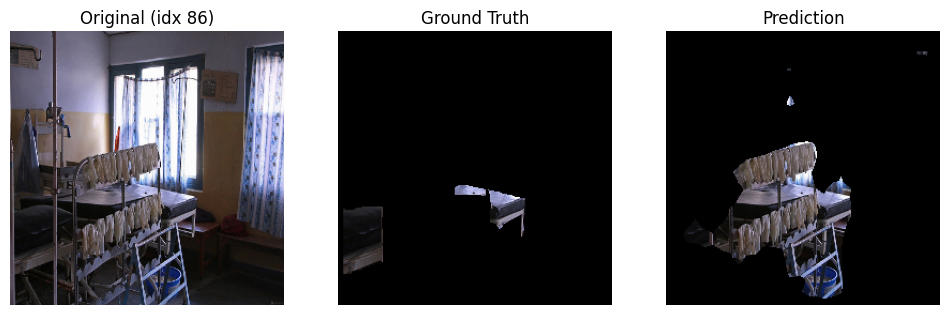

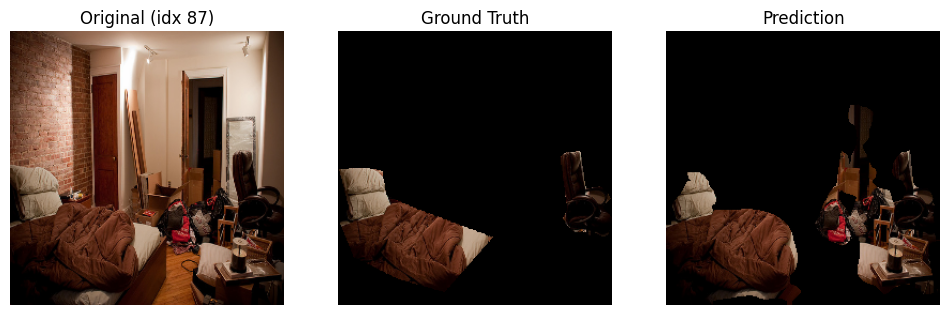

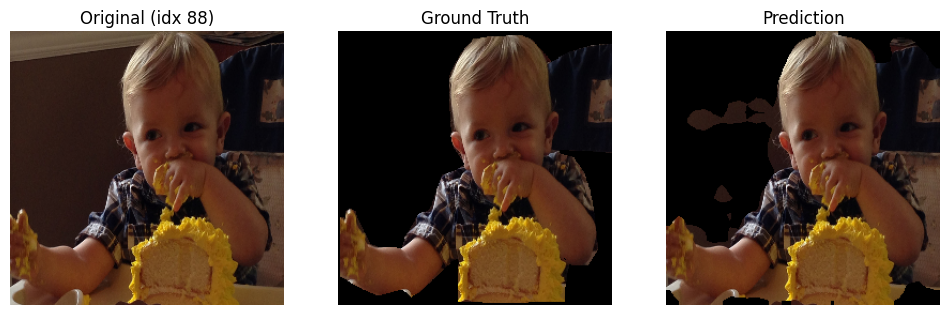

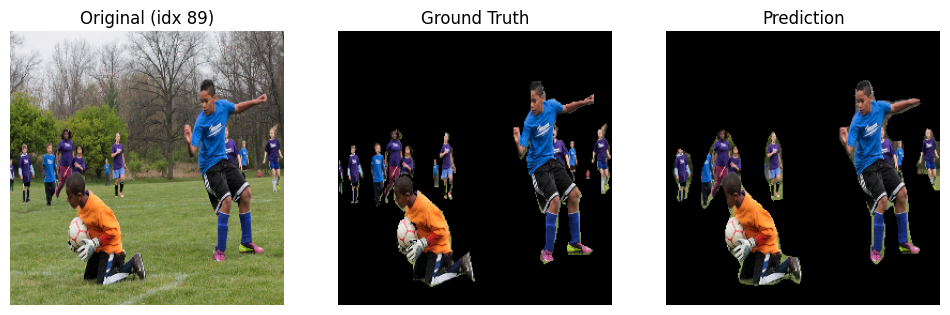

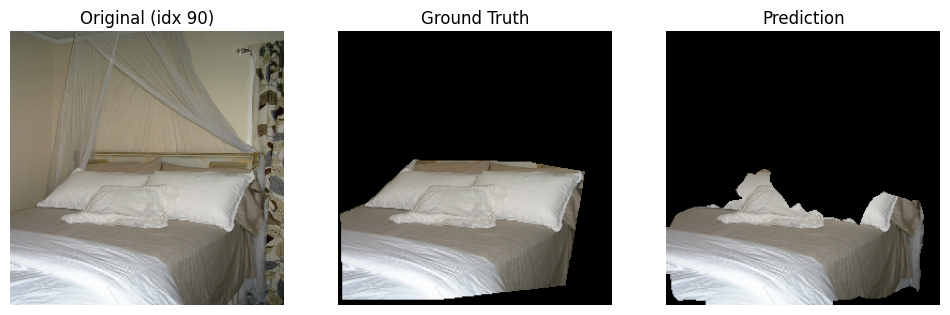

In [56]:
# === Fine-tune classifier head only (run this cell) ===
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Create a small training subset (50 samples or fewer if dataset smaller)
subset_size = min(100, len(dataset))
subset_indices = random.sample(range(len(dataset)), subset_size)
train_subset = Subset(dataset, subset_indices)
train_loader = DataLoader(train_subset, batch_size=4, shuffle=True, num_workers=2)

# Freeze everything except classifier and aux_classifier
for name, param in model.named_parameters():
    if ("classifier" in name) or ("aux_classifier" in name):
        param.requires_grad = True
    else:
        param.requires_grad = False

# Optimizer only for trainable params (the classifier head)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Train head for a few epochs
num_epochs = 30
model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)["out"]          # [B, C, H, W]
        loss = criterion(outputs, masks.long())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=running_loss / (loop.n + 1))

    print(f"Epoch {epoch+1}/{num_epochs}  avg_loss: {running_loss/len(train_loader):.4f}")

# Save the fine-tuned-head checkpoint
torch.save(model.state_dict(), "deeplabv3_custom_finetuned_head.pth")
print("✅ Saved: deeplabv3_custom_finetuned_head.pth")

# === Quick evaluation + visualization for dataset indices 20–25 ===
model.eval()
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

with torch.no_grad():
    for idx in range(70, 90):   # indices 19→24 == dataset samples 20→25
        img, mask = dataset[idx]
        img_input = img.unsqueeze(0).to(device)
        mask = mask.to(device)

        outputs = model(img_input)["out"]
        pred = torch.argmax(outputs, dim=1).cpu().squeeze().numpy()

        # Un-normalize for display
        img = img.permute(1,2,0).cpu().numpy()
        img = np.clip(img * std + mean, 0, 1)
        gt = mask.cpu().numpy()

        # Apply mask overlays
        gt_overlay = np.zeros_like(img)
        gt_overlay[gt == 1] = img[gt == 1]
        # Show all predicted classes except background (class 0)
        pred_overlay = np.zeros_like(img)
        pred_overlay[pred != 0] = img[pred != 0]


        # Plot side-by-side
        fig, axs = plt.subplots(1,3, figsize=(12,4))
        axs[0].imshow(img); axs[0].set_title(f"Original (idx {idx+1})"); axs[0].axis("off")
        axs[1].imshow(gt_overlay); axs[1].set_title("Ground Truth"); axs[1].axis("off")
        axs[2].imshow(pred_overlay); axs[2].set_title("Prediction"); axs[2].axis("off")
        plt.show()


Epoch 1/30  avg_loss: 0.3534


Epoch 2/30  avg_loss: 0.2187


Epoch 3/30  avg_loss: 0.1945


Epoch 4/30  avg_loss: 0.1634


Epoch 5/30  avg_loss: 0.1434


...

Epoch 26/30  avg_loss: 0.0730


Epoch 27/30  avg_loss: 0.0709


Epoch 28/30  avg_loss: 0.0707


Epoch 29/30  avg_loss: 0.0709


Epoch 30/30  avg_loss: 0.0713
✅ Saved: deeplabv3_custom_finetuned_head.pth


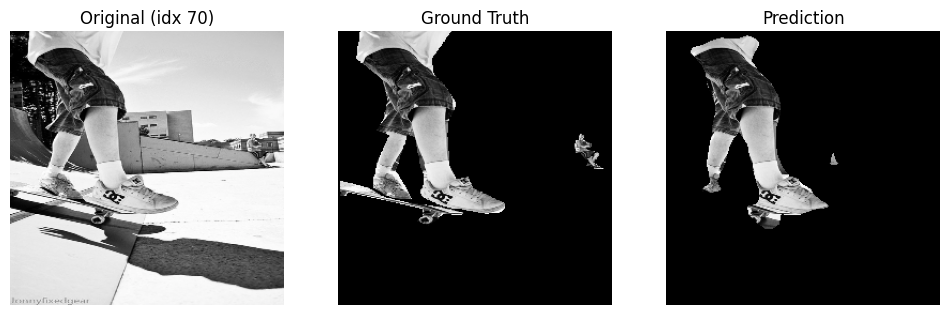

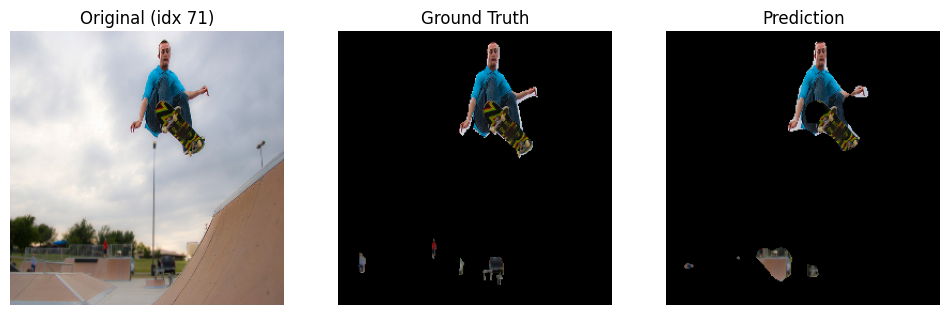

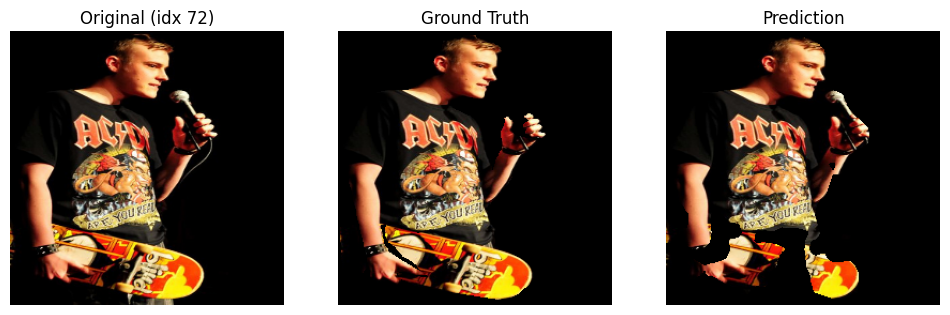

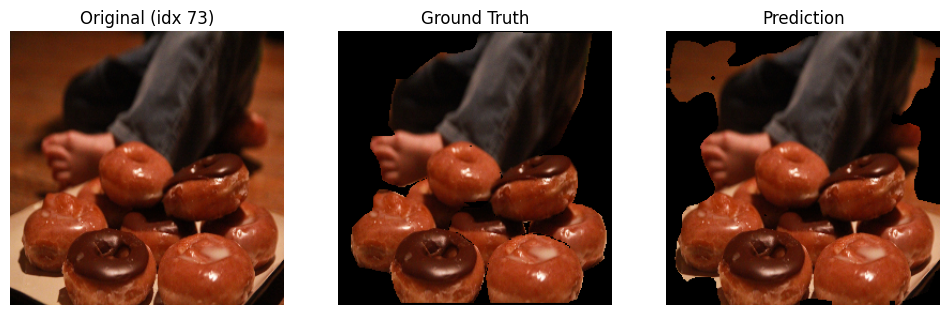

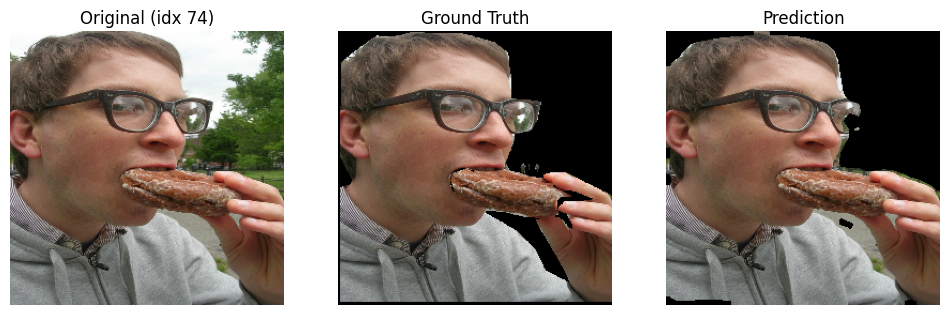

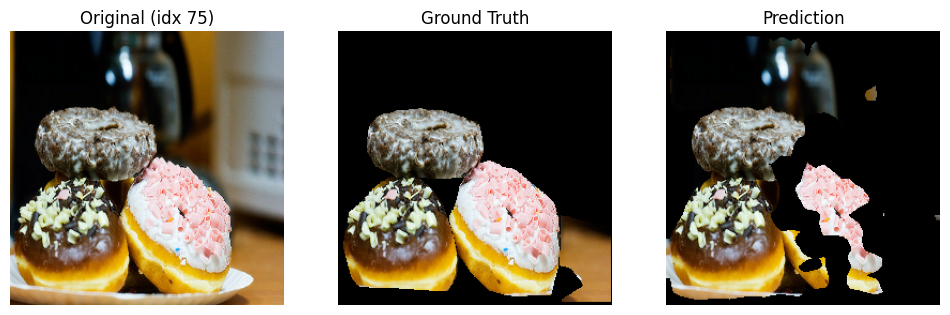

In [57]:
# === Fine-tune classifier head only ===
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# --- Create a small training subset (100 samples or fewer if dataset smaller)
subset_size = min(100, len(dataset))
subset_indices = random.sample(range(len(dataset)), subset_size)
train_subset = Subset(dataset, subset_indices)
train_loader = DataLoader(train_subset, batch_size=4, shuffle=True, num_workers=2)

# --- Freeze backbone, only train classifier heads
for name, param in model.named_parameters():
    if ("classifier" in name) or ("aux_classifier" in name):
        param.requires_grad = True
    else:
        param.requires_grad = False

# --- Optimizer & loss
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# --- Training loop
num_epochs = 30
model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)["out"]          # [B, C, H, W]
        loss = criterion(outputs, masks.long())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=running_loss / (loop.n + 1))

    print(f"Epoch {epoch+1}/{num_epochs}  avg_loss: {running_loss/len(train_loader):.4f}")

# --- Save checkpoint
torch.save(model.state_dict(), "deeplabv3_custom_finetuned_head.pth")
print("✅ Saved: deeplabv3_custom_finetuned_head.pth")

# ======================================================
# === Evaluation & visualization for selected indices ===
# ======================================================

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

model.eval()
with torch.no_grad():
    # 🔹 choose which indices to visualize
    selected_indices = [73, 74, 75, 77, 88]

    for idx in selected_indices:
        img, mask = dataset[idx]
        img_in = img.unsqueeze(0).to(device)
        mask = mask.to(device)

        outputs = model(img_in)["out"]
        pred = torch.argmax(outputs, dim=1).cpu().squeeze().numpy()

        # --- Un-normalize for display
        img_disp = img.permute(1,2,0).cpu().numpy()
        img_disp = np.clip(img_disp * std + mean, 0, 1)
        gt = mask.cpu().numpy()

        # --- Overlay (cutout style: keep original pixels where mask==class, else black)
        gt_overlay = np.zeros_like(img_disp)
        gt_overlay[gt == 1] = img_disp[gt == 1]

        pred_overlay = np.zeros_like(img_disp)
        pred_overlay[pred != 0] = img_disp[pred != 0]   # show all classes except background

        # --- Plot side-by-side
        fig, axs = plt.subplots(1,3, figsize=(12,4))
        axs[0].imshow(img_disp); axs[0].set_title(f"Original"); axs[0].axis("off")
        axs[1].imshow(gt_overlay); axs[1].set_title("Ground Truth"); axs[1].axis("off")
        axs[2].imshow(pred_overlay); axs[2].set_title("Prediction"); axs[2].axis("off")
        plt.show()


In [61]:
import torch
import numpy as np
from tqdm import tqdm

# ================================
# Metrics Implementation
# ================================
def evaluate_model(model, dataloader, device, num_classes=2):
    model.eval()
    iou_list = []
    dice_list = []
    total_correct = 0
    total_pixels = 0

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Evaluating"):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)["out"]
            preds = torch.argmax(outputs, dim=1)

            for pred, mask in zip(preds, masks):
                pred = pred.cpu().numpy()
                mask = mask.cpu().numpy()

                for cls in range(1, num_classes):  # skip background (class 0)
                    pred_cls = (pred == cls).astype(np.uint8)
                    mask_cls = (mask == cls).astype(np.uint8)

                    intersection = np.logical_and(pred_cls, mask_cls).sum()
                    union = np.logical_or(pred_cls, mask_cls).sum()
                    dice = (2 * intersection) / (pred_cls.sum() + mask_cls.sum() + 1e-6)

                    if union > 0:  # avoid division by zero
                        iou_list.append(intersection / union)
                    dice_list.append(dice)

                # Pixel accuracy
                total_correct += (pred == mask).sum()
                total_pixels += mask.size

    mean_iou = np.mean(iou_list) if iou_list else 0
    mean_dice = np.mean(dice_list) if dice_list else 0
    pixel_acc = total_correct / total_pixels

    return mean_iou, mean_dice, pixel_acc


# ================================
# Run Evaluation
# ================================
mean_iou, mean_dice, pixel_acc = evaluate_model(model, val_loader, device, num_classes=2)

print(f"✅ Evaluation Results:")
print(f"Mean IoU:   {mean_iou:.4f}")
print(f"Mean Dice:  {mean_dice:.4f}")
print(f"Pixel Acc:  {pixel_acc:.4f}")


Evaluating: 100%|██████████| 5000/5000 [07:23<00:00, 11.28it/s]

✅ Evaluation Results:
Mean IoU:   0.5724
Mean Dice:  0.6859
Pixel Acc:  0.8711
